In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import torch.nn as nn
import torchbnn 
from sklearn.datasets import load_breast_cancer
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, f1_score, roc_curve, auc
from sklearn.preprocessing import StandardScaler

In [41]:
dataset = load_breast_cancer(as_frame=True)
Y = dataset['target']
dataset = dataset['data']
print(dataset.columns)
print(dataset.describe())
dataset.drop(dataset.columns[10:],axis=1, inplace=True)

numpy_dataset = dataset.to_numpy()
Y = Y.to_numpy() # 1 = Benign, 0 = Maligant

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension'],
      dtype='object')
       mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.70

In [42]:
dataset.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440


In [43]:
X_train, X_test, y_train, y_test = train_test_split(numpy_dataset, Y, test_size=0.3, random_state=42)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test  = torch.tensor(X_test,  dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long).squeeze()
y_test  = torch.tensor(y_test,  dtype=torch.long).squeeze()

In [44]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test  = torch.tensor(X_test,  dtype=torch.float32)

In [45]:
# Split into validation data
X_train, X_val = X_train[:int(len(X_train)*0.8)], X_train[int(len(X_train)*0.8):]
y_train, y_val = y_train[:int(len(y_train)*0.8)], y_train[int(len(y_train)*0.8):]
print(X_train.shape, X_val.shape)
print(y_train.shape, y_val.shape)

torch.Size([318, 10]) torch.Size([80, 10])
torch.Size([318]) torch.Size([80])


### BNN

In [ ]:
# Hyperparameter optimisation

for lr in [0.1, 0.01, 0.001, 0.0001]:
    for kl_weight in [0.1, 0.01, 0.001, 0.0001]:
        bnn_model =nn.Sequential(
            torchbnn.BayesLinear(prior_mu=0, prior_sigma=0.1, in_features=10, out_features=32), 
            nn.ReLU(),
            #torchbnn.BayesLinear(prior_mu=0, prior_sigma=0.1, in_features=64, out_features=32),
            #nn.ReLU(),
            torchbnn.BayesLinear(prior_mu=0, prior_sigma=0.1, in_features=32, out_features=2),
            )

        ce_loss = nn.CrossEntropyLoss()
        kl_loss   = torchbnn.BKLLoss(reduction="mean", last_layer_only=False)
        #kl_weight = 0.001

        optimizer = torch.optim.Adam(bnn_model.parameters(), lr=lr)

        num_epochs = 20

        for epoch in range(num_epochs):
            # Training on training data
            bnn_model.train()
            predictions = bnn_model(X_train)
            loss = ce_loss(predictions, y_train) + kl_weight * kl_loss(bnn_model)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            # Evaluation on validation data
            bnn_model.eval()
            n_samples = 50

            with torch.no_grad():
                predictions_val = torch.stack([bnn_model(X_val) for _ in range(n_samples)])

            probs = torch.softmax(predictions, dim=-1)
            mean_prods = torch.mean(predictions_val, dim=0)
            predicted_classes = torch.argmax(mean_prods, dim=1)

        print(f'For lr = {lr} and KL weight {kl_weight}:')
        print(f'Recall = {recall_score(y_val, predicted_classes)*100:.4f}%')
        print(f'F1 Score: {f1_score(y_val, predicted_classes):.4f}\n')
        


For lr = 0.1 and KL weight 0.1:
Recall = 94.1176%
F1 Score: 0.9600

For lr = 0.1 and KL weight 0.01:
Recall = 92.1569%
F1 Score: 0.9400

For lr = 0.1 and KL weight 0.001:
Recall = 94.1176%
F1 Score: 0.9143

For lr = 0.1 and KL weight 0.0001:
Recall = 92.1569%
F1 Score: 0.9495

For lr = 0.01 and KL weight 0.1:
Recall = 100.0000%
F1 Score: 0.9714

For lr = 0.01 and KL weight 0.01:
Recall = 96.0784%
F1 Score: 0.9608

For lr = 0.01 and KL weight 0.001:
Recall = 100.0000%
F1 Score: 0.9808

For lr = 0.01 and KL weight 0.0001:
Recall = 98.0392%
F1 Score: 0.9615

For lr = 0.001 and KL weight 0.1:
Recall = 0.0000%
F1 Score: 0.0000

For lr = 0.001 and KL weight 0.01:
Recall = 82.3529%
F1 Score: 0.8936

For lr = 0.001 and KL weight 0.001:
Recall = 66.6667%
F1 Score: 0.6869

For lr = 0.001 and KL weight 0.0001:
Recall = 98.0392%
F1 Score: 0.8772

For lr = 0.0001 and KL weight 0.1:
Recall = 98.0392%
F1 Score: 0.8197

For lr = 0.0001 and KL weight 0.01:
Recall = 13.7255%
F1 Score: 0.2373

For lr = 0

Epoch 1/20 | Train Loss: 0.9046 | Val Loss: 0.6852
Epoch 2/20 | Train Loss: 0.8655 | Val Loss: 0.5877
Epoch 3/20 | Train Loss: 0.7053 | Val Loss: 0.5255
Epoch 4/20 | Train Loss: 0.6074 | Val Loss: 0.4652
Epoch 5/20 | Train Loss: 0.7097 | Val Loss: 0.4269
Epoch 6/20 | Train Loss: 0.4456 | Val Loss: 0.3874
Epoch 7/20 | Train Loss: 0.4939 | Val Loss: 0.3504
Epoch 8/20 | Train Loss: 0.4310 | Val Loss: 0.3154
Epoch 9/20 | Train Loss: 0.3136 | Val Loss: 0.3032
Epoch 10/20 | Train Loss: 0.3078 | Val Loss: 0.2793
Epoch 11/20 | Train Loss: 0.3934 | Val Loss: 0.2652
Epoch 12/20 | Train Loss: 0.2896 | Val Loss: 0.2454
Epoch 13/20 | Train Loss: 0.2741 | Val Loss: 0.2256
Epoch 14/20 | Train Loss: 0.2535 | Val Loss: 0.2164
Epoch 15/20 | Train Loss: 0.2439 | Val Loss: 0.2050
Epoch 16/20 | Train Loss: 0.2123 | Val Loss: 0.2040
Epoch 17/20 | Train Loss: 0.2030 | Val Loss: 0.1863
Epoch 18/20 | Train Loss: 0.2107 | Val Loss: 0.1809
Epoch 19/20 | Train Loss: 0.2259 | Val Loss: 0.1714
Epoch 20/20 | Train L

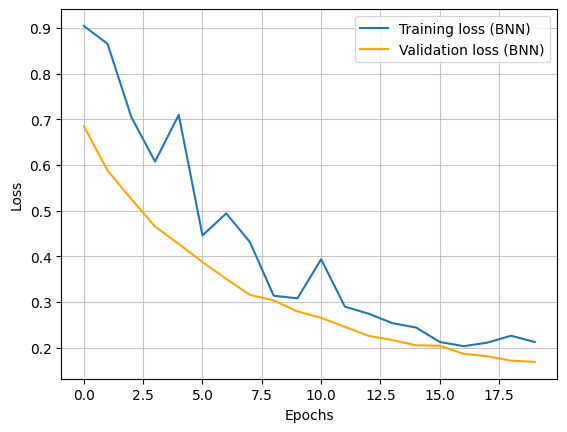

In [ ]:

bnn_model = nn.Sequential(
    torchbnn.BayesLinear(prior_mu=0, prior_sigma=0.1, in_features=10, out_features=32),
    nn.ReLU(),
    torchbnn.BayesLinear(prior_mu=0, prior_sigma=0.1, in_features=32, out_features=2),
)

ce_loss = nn.CrossEntropyLoss()
kl_loss = torchbnn.BKLLoss(reduction="mean", last_layer_only=False)
kl_weight = 0.001

optimizer = torch.optim.Adam(bnn_model.parameters(), lr=0.01)

num_epochs = 20
training_loss_bnn = []
validation_loss_bnn = []

# Training loop
for epoch in range(num_epochs):

    # -------- TRAINING --------
    bnn_model.train()

    predictions = bnn_model(X_train)

    loss = ce_loss(predictions, y_train) + kl_weight * kl_loss(bnn_model)

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    training_loss_bnn.append(loss.item())

    # -------- VALIDATION --------
    bnn_model.eval()
    n_samples = 50

    with torch.no_grad():
        predictions_val = torch.stack(
            [bnn_model(X_val) for _ in range(n_samples)]
        )

    mean_logits = torch.mean(predictions_val, dim=0)

    val_loss = ce_loss(mean_logits, y_val) + kl_weight * kl_loss(bnn_model)

    validation_loss_bnn.append(val_loss.item())

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {loss.item():.4f} | "
        f"Val Loss: {val_loss.item():.4f}"
    )

# Final Evaluation
bnn_model.eval()

n_samples = 50

with torch.no_grad():
    predictions_test = torch.stack(
        [bnn_model(X_test) for _ in range(n_samples)]
    )

mean_logits = torch.mean(predictions_test, dim=0)

# Convert to probabilities
mean_probs = torch.softmax(mean_logits, dim=1)

predicted_classes = torch.argmax(mean_probs, dim=1)

# Entopy (Uncertainity)
H_p = -torch.sum(mean_probs * torch.log(mean_probs + 1e-10), dim=1)

correct_idx = predicted_classes == y_test

print(f"Recall = {recall_score(y_test, predicted_classes)*100:.4f}%")
print(f"F1 Score = {f1_score(y_test, predicted_classes):.4f}")

print(
    f"Uncertainty (correct predictions): "
    f"{torch.mean(H_p[correct_idx]):.3f}"
)

print(
    f"Uncertainty (incorrect predictions): "
    f"{torch.mean(H_p[~correct_idx]):.3f}"
)

plt.figure()
plt.plot(range(num_epochs), training_loss_bnn, color='tab:blue', label='Training loss (BNN)')
plt.plot(range(num_epochs), validation_loss_bnn, color='orange', label='Validation loss (BNN)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True, alpha=0.75)
plt.legend()
plt.savefig('training_validation_loss_bnn.jpg', dpi=300, bbox_inches='tight')
plt.show()

AUC: 0.9398148148148148


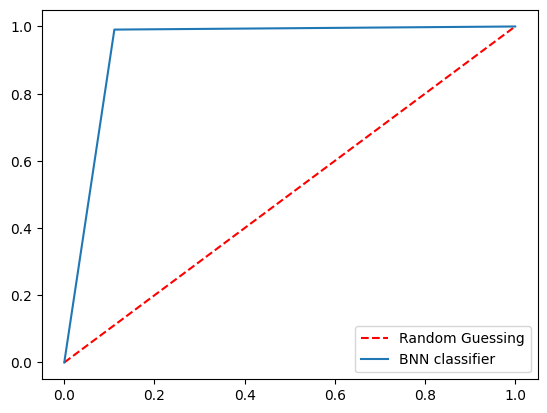

In [55]:
fpr_bnn, tpr_bnn, _ = roc_curve(y_test, predicted_classes)
print(f'AUC: {auc(fpr_bnn, tpr_bnn)}')

plt.figure()
plt.plot([0,1], [0,1], 'r--', label='Random Guessing')
plt.plot(fpr_bnn, tpr_bnn, label='BNN classifier')
plt.legend(loc='lower right')
plt.show()

### NN

In [58]:
for lr in [0.1, 0.01, 0.001, 0.0001]:

    nn_model = nn.Sequential(
        nn.Linear(10, 32),
        nn.ReLU(),
        nn.Linear(32, 2)
    )

    ce_loss_nn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(nn_model.parameters(), lr=lr)

    for epoch in range(num_epochs):

        nn_model.train()

        predictions = nn_model(X_train)

        loss = ce_loss_nn(predictions, y_train)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    # ---- VALIDATION ----
    nn_model.eval()

    with torch.no_grad():
        predictions_val_nn = nn_model(X_val)

    probs_nn = torch.softmax(predictions_val_nn, dim=1)
    final_predictions_nn = torch.argmax(probs_nn, dim=1)

    print(f'lr = {lr}')
    print(f'Recall: {recall_score(y_val, final_predictions_nn)*100:.4f}%')
    print(f'F1 Score: {f1_score(y_val, final_predictions_nn):.4f}\n')

lr = 0.1
Recall: 96.0784%
F1 Score: 0.9608

lr = 0.01
Recall: 96.0784%
F1 Score: 0.9703

lr = 0.001
Recall: 94.1176%
F1 Score: 0.8807

lr = 0.0001
Recall: 100.0000%
F1 Score: 0.7786



Epoch 1/20 | Train Loss: 0.7136 | Val Loss: 0.6238
Epoch 2/20 | Train Loss: 0.6205 | Val Loss: 0.5472
Epoch 3/20 | Train Loss: 0.5474 | Val Loss: 0.4860
Epoch 4/20 | Train Loss: 0.4870 | Val Loss: 0.4344
Epoch 5/20 | Train Loss: 0.4353 | Val Loss: 0.3892
Epoch 6/20 | Train Loss: 0.3900 | Val Loss: 0.3485
Epoch 7/20 | Train Loss: 0.3497 | Val Loss: 0.3121
Epoch 8/20 | Train Loss: 0.3143 | Val Loss: 0.2801
Epoch 9/20 | Train Loss: 0.2838 | Val Loss: 0.2523
Epoch 10/20 | Train Loss: 0.2582 | Val Loss: 0.2287
Epoch 11/20 | Train Loss: 0.2371 | Val Loss: 0.2089
Epoch 12/20 | Train Loss: 0.2202 | Val Loss: 0.1923
Epoch 13/20 | Train Loss: 0.2069 | Val Loss: 0.1787
Epoch 14/20 | Train Loss: 0.1965 | Val Loss: 0.1675
Epoch 15/20 | Train Loss: 0.1885 | Val Loss: 0.1584
Epoch 16/20 | Train Loss: 0.1823 | Val Loss: 0.1512
Epoch 17/20 | Train Loss: 0.1776 | Val Loss: 0.1454
Epoch 18/20 | Train Loss: 0.1739 | Val Loss: 0.1409
Epoch 19/20 | Train Loss: 0.1708 | Val Loss: 0.1375
Epoch 20/20 | Train L

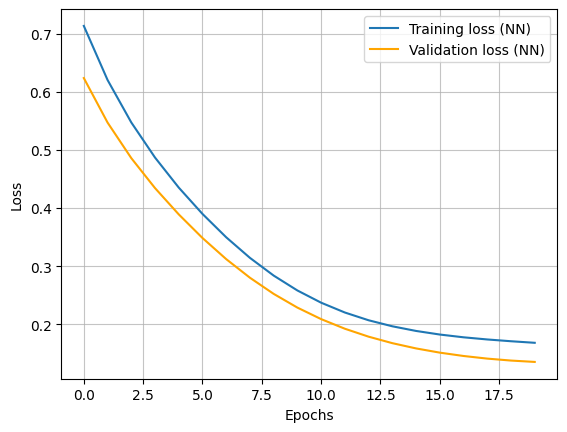

In [ ]:
nn_model = nn.Sequential(
    nn.Linear(10, 32),
    nn.ReLU(),
    nn.Linear(32, 2),
)

ce_loss = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(nn_model.parameters(), lr=0.01)

num_epochs = 20
training_loss_nn = []
validation_loss_nn = []

# Training Loop
for epoch in range(num_epochs):

    # -------- TRAINING --------
    nn_model.train()

    predictions = nn_model(X_train)

    loss = ce_loss(predictions, y_train)

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    training_loss_nn.append(loss.item())

    # -------- VALIDATION --------
    nn_model.eval()

    with torch.no_grad():
        predictions_val = nn_model(X_val)

    val_loss = ce_loss(predictions_val, y_val)

    validation_loss_nn.append(val_loss.item())

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {loss.item():.4f} | "
        f"Val Loss: {val_loss.item():.4f}"
    )

# Testing
nn_model.eval()

with torch.no_grad():
    predictions_test = nn_model(X_test)

# Convert logits → probabilities
probs = torch.softmax(predictions_test, dim=1)

predicted_classes = torch.argmax(probs, dim=1)

print(f"Recall = {recall_score(y_test, predicted_classes)*100:.4f}%")
print(f"F1 Score = {f1_score(y_test, predicted_classes):.4f}")

plt.figure()
plt.plot(range(num_epochs), training_loss_nn, color='tab:blue', label='Training loss (NN)')
plt.plot(range(num_epochs), validation_loss_nn, color='orange', label='Validation loss (NN)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True, alpha=0.75)
plt.legend()
plt.savefig('training_validation_loss_nn.jpg', dpi=300, bbox_inches='tight')
plt.show()

AUC: 0.9464285714285715


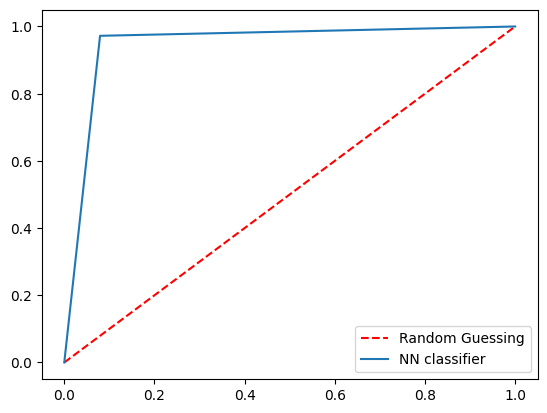

In [62]:
fpr_nn, tpr_nn, _ = roc_curve(y_test, predicted_classes)

print(f'AUC: {auc(fpr_nn, tpr_nn)}')

plt.figure()
plt.plot([0,1], [0,1], 'r--', label='Random Guessing')
plt.plot(fpr_nn, tpr_nn, label='NN classifier')
plt.legend(loc='lower right')
plt.show()

### Combined ROC

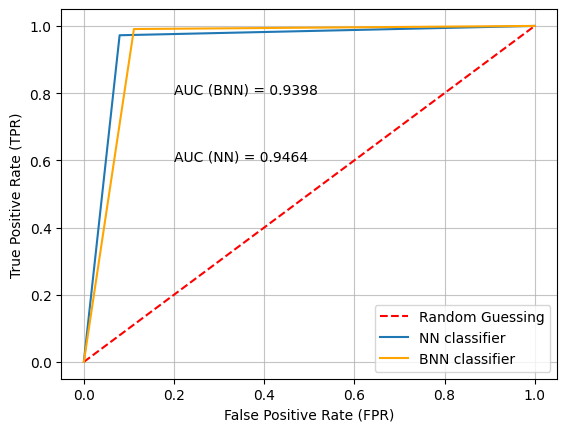

In [68]:
plt.figure()
plt.plot([0,1], [0,1], 'r--', label='Random Guessing')
plt.plot(fpr_nn, tpr_nn, color='tab:blue', label='NN classifier')
plt.plot(fpr_bnn, tpr_bnn, color='orange', label='BNN classifier')
plt.grid(True, alpha=0.75)
plt.legend(loc='lower right')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.text(0.2, 0.8, f'AUC (BNN) = {auc(fpr_bnn, tpr_bnn):.4f}')
plt.text(0.2, 0.6, f'AUC (NN) = {auc(fpr_nn, tpr_nn):.4f}')
plt.savefig('ROC_curve_nn_and_bnn.jpg', dpi=300, bbox_inches='tight')
plt.show()

# Final Results 

Changing training set size whilst keeping the validation and testing size the same.

In [17]:
def train_val_test_dataset(training_size: float):
    dataset = load_breast_cancer(as_frame=True)
    Y = dataset['target']
    X = dataset['data']
    X.drop(X.columns[10:],axis=1, inplace=True)

    X_train_full, X_test, y_train_full, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

    X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=(1 - training_size),random_state=42)

    print(X_train.shape, X_val.shape, X_test.shape)
    print(y_train.shape, y_val.shape, y_test.shape)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    X_train = torch.tensor(X_train, dtype=torch.float32)
    X_val = torch.tensor(X_val, dtype=torch.float32)
    X_test = torch.tensor(X_test, dtype=torch.float32)    
    y_train = torch.tensor(y_train.values, dtype=torch.long)
    y_val = torch.tensor(y_val.values, dtype=torch.long)
    y_test = torch.tensor(y_test.values, dtype=torch.long)

    print(X_train.shape, X_val.shape, X_test.shape)
    print(y_train.shape, y_val.shape, y_test.shape)

    counts_1 = torch.count_nonzero(y_train)
    counts_0 = len(y_train)-counts_1
    print(counts_1, counts_0)
    
    return (X_train, X_val), (y_train, y_val), (X_test, y_test)

In [30]:
for i in [0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1, 0.05]:
    (X_train, X_val), (y_train, y_val), (X_test, y_test) = train_val_test_dataset(training_size=i)
    print('\n')

(278, 10) (120, 10) (171, 10)
(278,) (120,) (171,)
torch.Size([278, 10]) torch.Size([120, 10]) torch.Size([171, 10])
torch.Size([278]) torch.Size([120]) torch.Size([171])
tensor(178) tensor(100)


(238, 10) (160, 10) (171, 10)
(238,) (160,) (171,)
torch.Size([238, 10]) torch.Size([160, 10]) torch.Size([171, 10])
torch.Size([238]) torch.Size([160]) torch.Size([171])
tensor(150) tensor(88)


(199, 10) (199, 10) (171, 10)
(199,) (199,) (171,)
torch.Size([199, 10]) torch.Size([199, 10]) torch.Size([171, 10])
torch.Size([199]) torch.Size([199]) torch.Size([171])
tensor(122) tensor(77)


(159, 10) (239, 10) (171, 10)
(159,) (239,) (171,)
torch.Size([159, 10]) torch.Size([239, 10]) torch.Size([171, 10])
torch.Size([159]) torch.Size([239]) torch.Size([171])
tensor(98) tensor(61)


(119, 10) (279, 10) (171, 10)
(119,) (279,) (171,)
torch.Size([119, 10]) torch.Size([279, 10]) torch.Size([171, 10])
torch.Size([119]) torch.Size([279]) torch.Size([171])
tensor(67) tensor(52)


(79, 10) (319, 10) (1

## BNN

In [11]:
def train_BNN(X_train, X_val, X_test, y_train, y_val, y_test):
    bnn_model =nn.Sequential(
        torchbnn.BayesLinear(prior_mu=0, prior_sigma=0.1, in_features=10, out_features=32), 
        nn.ReLU(),
        torchbnn.BayesLinear(prior_mu=0, prior_sigma=0.1, in_features=32, out_features=2),
        )
    
    ce_loss = nn.CrossEntropyLoss()
    kl_loss   = torchbnn.BKLLoss(reduction="mean", last_layer_only=False)
    kl_weight = 0.001
    optimizer = torch.optim.Adam(bnn_model.parameters(), lr=0.01)
    num_epochs = 20

    for epoch in range(num_epochs):
        # Training
        bnn_model.train()
        predictions = bnn_model(X_train)
        loss = ce_loss(predictions, y_train) + kl_weight*kl_loss(bnn_model)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        num_samples = 50
        # Validation
        bnn_model.eval()
        with torch.no_grad():
            predictions = torch.stack([bnn_model(X_val) for _ in range(num_samples)])

            mean_logits = torch.mean(predictions, dim=0)
            val_loss = ce_loss(mean_logits, y_val) + kl_weight*kl_loss(bnn_model)

        print(f'Epoch = {epoch+1}\t Loss = {loss.item():.4f}\t Val Loss = {val_loss.item():.4f}')

    bnn_model.eval()
    with torch.no_grad():
        predictions = torch.stack([bnn_model(X_test) for _ in range(num_samples)])

    mean_logits = torch.mean(predictions, dim=0)
    mean_probs = torch.softmax(mean_logits, dim=1)
    predicted_classes = torch.argmax(mean_probs, dim=1)

    # Entropy 
    H_p = -torch.sum(mean_probs * torch.log(mean_probs), dim=1)

    correct_idx = predicted_classes == y_test

    print(f"Recall = {recall_score(y_test, predicted_classes)*100:.4f}%")
    print(f"F1 Score = {f1_score(y_test, predicted_classes):.4f}")
    print(f"Uncertainty (correct predictions): {torch.mean(H_p[correct_idx]):.3f}")
    print(f"Uncertainty (incorrect predictions): {torch.mean(H_p[~correct_idx]):.3f}")




In [12]:
import warnings
warnings.filterwarnings('ignore')

for size in [0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1, 0.05]:
    print('Training set size = {}'.format(size))
    (X_train, X_val), (y_train, y_val), (X_test, y_test) = train_val_test_dataset(training_size=size)
    train_BNN(X_train, X_val, X_test, y_train, y_val, y_test)
    print('\n')

Training set size = 0.7
(278, 10) (120, 10) (171, 10)
(278,) (120,) (171,)
torch.Size([278, 10]) torch.Size([120, 10]) torch.Size([171, 10])
torch.Size([278]) torch.Size([120]) torch.Size([171])
Epoch = 1	 Loss = 0.6642	 Val Loss = 0.5746
Epoch = 2	 Loss = 0.4679	 Val Loss = 0.5368
Epoch = 3	 Loss = 0.5465	 Val Loss = 0.4897
Epoch = 4	 Loss = 0.4469	 Val Loss = 0.4359
Epoch = 5	 Loss = 0.4224	 Val Loss = 0.4093
Epoch = 6	 Loss = 0.3991	 Val Loss = 0.3701
Epoch = 7	 Loss = 0.3554	 Val Loss = 0.3340
Epoch = 8	 Loss = 0.3304	 Val Loss = 0.3098
Epoch = 9	 Loss = 0.2460	 Val Loss = 0.2815
Epoch = 10	 Loss = 0.2677	 Val Loss = 0.2640
Epoch = 11	 Loss = 0.2776	 Val Loss = 0.2523
Epoch = 12	 Loss = 0.2339	 Val Loss = 0.2416
Epoch = 13	 Loss = 0.2042	 Val Loss = 0.2321
Epoch = 14	 Loss = 0.2071	 Val Loss = 0.2247
Epoch = 15	 Loss = 0.2025	 Val Loss = 0.2196
Epoch = 16	 Loss = 0.1890	 Val Loss = 0.2132
Epoch = 17	 Loss = 0.1551	 Val Loss = 0.2121
Epoch = 18	 Loss = 0.1535	 Val Loss = 0.2123
Epoc

## NN

In [13]:
def train_NN(X_train, X_val, X_test, y_train, y_val, y_test):
    nn_model = nn.Sequential(
    nn.Linear(10, 32),
    nn.ReLU(),
    nn.Linear(32, 2)
    )
    
    ce_loss = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(nn_model.parameters(), lr=0.01)
    num_epochs = 20

    for epoch in range(num_epochs):
        # Training
        nn_model.train()
        predictions = nn_model(X_train)
        loss = ce_loss(predictions, y_train)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        num_samples = 50
        # Validation
        nn_model.eval()
        with torch.no_grad():
            predictions = nn_model(X_val)
            val_loss = ce_loss(predictions, y_val)

        print(f'Epoch = {epoch+1}\t Loss = {loss.item():.4f}\t Val Loss = {val_loss.item():.4f}')

    nn_model.eval()
    with torch.no_grad():
        predictions = nn_model(X_test)

        logits = predictions
        probs = torch.softmax(logits, dim=1)
        predicted_classes = torch.argmax(probs, dim=1)

    print(f"Recall = {recall_score(y_test, predicted_classes)*100:.4f}%")
    print(f"F1 Score = {f1_score(y_test, predicted_classes):.4f}")




In [14]:
for size in [0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1, 0.05]:
    print('Training set size = {}'.format(size))
    (X_train, X_val), (y_train, y_val), (X_test, y_test) = train_val_test_dataset(training_size=size)
    train_NN(X_train, X_val, X_test, y_train, y_val, y_test)
    print('\n')

Training set size = 0.7
(278, 10) (120, 10) (171, 10)
(278,) (120,) (171,)
torch.Size([278, 10]) torch.Size([120, 10]) torch.Size([171, 10])
torch.Size([278]) torch.Size([120]) torch.Size([171])
Epoch = 1	 Loss = 0.6806	 Val Loss = 0.6225
Epoch = 2	 Loss = 0.6108	 Val Loss = 0.5709
Epoch = 3	 Loss = 0.5487	 Val Loss = 0.5236
Epoch = 4	 Loss = 0.4922	 Val Loss = 0.4796
Epoch = 5	 Loss = 0.4400	 Val Loss = 0.4385
Epoch = 6	 Loss = 0.3921	 Val Loss = 0.4006
Epoch = 7	 Loss = 0.3488	 Val Loss = 0.3663
Epoch = 8	 Loss = 0.3105	 Val Loss = 0.3363
Epoch = 9	 Loss = 0.2776	 Val Loss = 0.3110
Epoch = 10	 Loss = 0.2500	 Val Loss = 0.2900
Epoch = 11	 Loss = 0.2275	 Val Loss = 0.2731
Epoch = 12	 Loss = 0.2094	 Val Loss = 0.2599
Epoch = 13	 Loss = 0.1952	 Val Loss = 0.2498
Epoch = 14	 Loss = 0.1841	 Val Loss = 0.2420
Epoch = 15	 Loss = 0.1756	 Val Loss = 0.2362
Epoch = 16	 Loss = 0.1691	 Val Loss = 0.2318
Epoch = 17	 Loss = 0.1640	 Val Loss = 0.2283
Epoch = 18	 Loss = 0.1600	 Val Loss = 0.2257
Epoc